In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("../outputs", exist_ok=True)

In [15]:
result_dir = "../outputs/model_results"

resnet = pd.read_csv(os.path.join(result_dir, "resnet18_results.csv"))
densenet = pd.read_csv(os.path.join(result_dir, "densenet121_results.csv"))
efficientnet = pd.read_csv(os.path.join(result_dir, "efficientnet_b0_results.csv"))

all_results = pd.concat(
    [resnet, densenet, efficientnet],
    ignore_index=True
)

all_results

,Model,Epoch,Best Validation Accuracy,Final Validation Accuracy
0,ResNet18,5,92.242991,92.242991
1,ResNet18,10,94.018692,93.551402
2,DenseNet121,5,89.813084,89.719626
3,DenseNet121,10,92.710280,92.710280
4,EfficientNet-B0,5,86.822430,85.046729
5,EfficientNet-B0,10,90.934579,90.934579


In [16]:
results_5epoch = all_results[
    all_results["Epoch"] == 5
].reset_index(drop=True)

results_5epoch

,Model,Epoch,Best Validation Accuracy,Final Validation Accuracy
0,ResNet18,5,92.242991,92.242991
1,DenseNet121,5,89.813084,89.719626
2,EfficientNet-B0,5,86.822430,85.046729


In [17]:
results_10epoch = all_results[
    all_results["Epoch"] == 10
].reset_index(drop=True)

results_10epoch

,Model,Epoch,Best Validation Accuracy,Final Validation Accuracy
0,ResNet18,10,94.018692,93.551402
1,DenseNet121,10,92.710280,92.710280
2,EfficientNet-B0,10,90.934579,90.934579


## 5 Epoch Model Comparison Result

After training all models for 5 epochs, DenseNet121 achieved the highest validation accuracy with 92.62%. ResNet18 followed very closely with 92.52%, while EfficientNet-B0 reached 89.72%.

Therefore, DenseNet121 was selected as the best-performing model based on validation accuracy. However, the difference between DenseNet121 and ResNet18 was very small, which shows that both models performed strongly on this dataset.

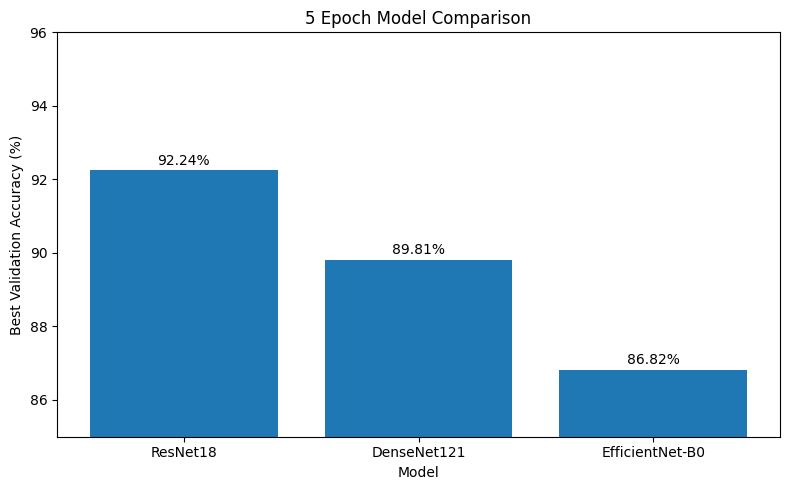

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_5epoch["Model"],
    results_5epoch["Best Validation Accuracy"]
)

plt.title("5 Epoch Model Comparison")
plt.xlabel("Model")
plt.ylabel("Best Validation Accuracy (%)")
plt.ylim(85, 96)

for i, value in enumerate(results_5epoch["Best Validation Accuracy"]):
    plt.text(i, value + 0.15, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("../outputs/5epoch_model_comparison.png")
plt.show()

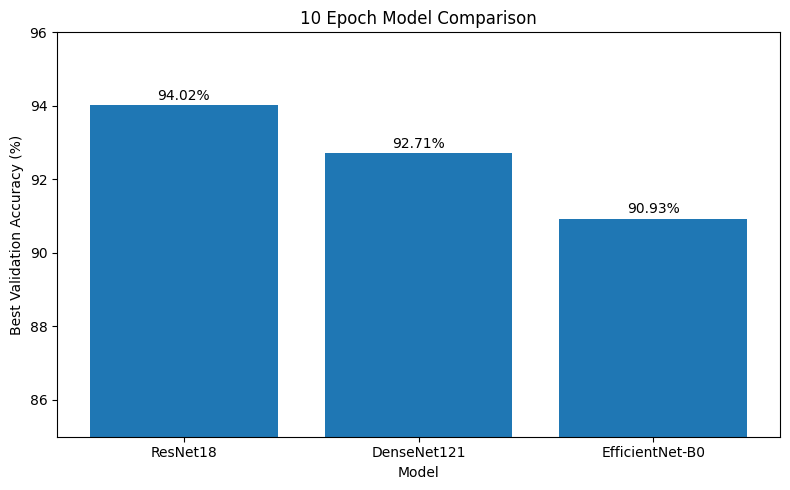

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_10epoch["Model"],
    results_10epoch["Best Validation Accuracy"]
)

plt.title("10 Epoch Model Comparison")
plt.xlabel("Model")
plt.ylabel("Best Validation Accuracy (%)")
plt.ylim(85, 96)

for i, value in enumerate(results_10epoch["Best Validation Accuracy"]):
    plt.text(i, value + 0.15, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("../outputs/10epoch_model_comparison.png")
plt.show()

In [20]:
pivot_results = all_results.pivot(
    index="Model",
    columns="Epoch",
    values="Best Validation Accuracy"
)

pivot_results

Epoch,5,10
Model,,
DenseNet121,89.813084,92.710280
EfficientNet-B0,86.822430,90.934579
ResNet18,92.242991,94.018692


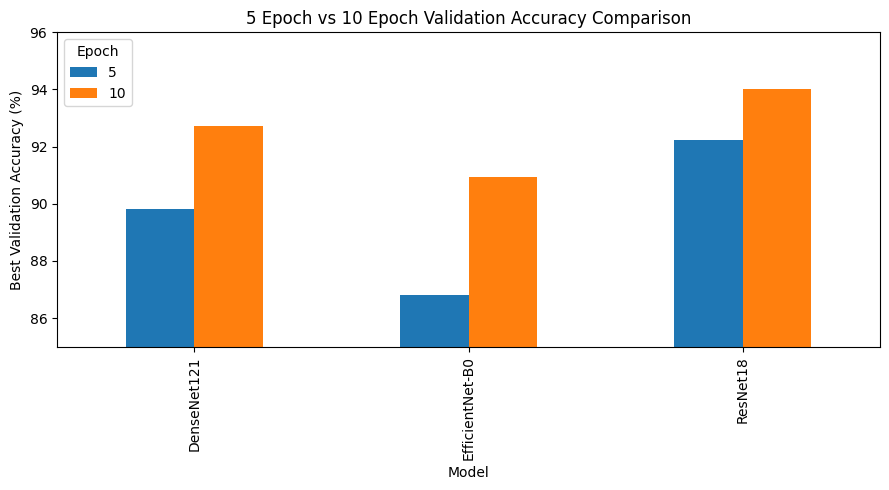

In [21]:
pivot_results.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("5 Epoch vs 10 Epoch Validation Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Best Validation Accuracy (%)")
plt.ylim(85, 96)
plt.legend(title="Epoch")

plt.tight_layout()
plt.savefig("../outputs/5epoch_vs_10epoch_model_comparison.png")
plt.show()

In [22]:
best_model = all_results.loc[
    all_results["Best Validation Accuracy"].idxmax()
]

print("FINAL BEST MODEL")
print("----------------")
print("Model:", best_model["Model"])
print("Epoch:", best_model["Epoch"])
print("Best Validation Accuracy:", round(best_model["Best Validation Accuracy"], 2))
print("Final Validation Accuracy:", round(best_model["Final Validation Accuracy"], 2))

FINAL BEST MODEL
----------------
Model: ResNet18
Epoch: 10
Best Validation Accuracy: 94.02
Final Validation Accuracy: 93.55


## Final Model Comparison Result

The comparison notebook automatically reads the result CSV files generated by each model notebook. According to the best validation accuracy values, the models were compared for both 5 epochs and 10 epochs.

The final best-performing model was selected based on the highest best validation accuracy. This approach is more reliable than manually entering values because the comparison table and graphs are generated directly from saved experiment results.